In [ ]:
!pip install ucimlrepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
import numpy as np
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import uniform
from scipy.spatial.transform import Rotation as R
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay)
from sklearn import svm, linear_model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree # for tree.plot_tree()
from sklearn.model_selection import (train_test_split, cross_val_score,GridSearchCV, RandomizedSearchCV)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine

from scipy.stats import uniform

In [ ]:
wdbc = fetch_ucirepo(id=17)
X = wdbc.data.features
y = wdbc.data.targets
features= ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
columns=[f'{stat}_{f}' for stat in ['mean', 'se', 'worst'] for f in features]
X.columns= columns
cancer_df = pd.concat([y, X], axis=1)
cancer_df = cancer_df.rename(columns={'Diagnosis': 'diagnosis'})
cancer_df['diagnosis_binary'] = cancer_df['diagnosis'].map({'M': 1, 'B': 0})
print(cancer_df.shape)
print(cancer_df.head())

(569, 32)
  diagnosis  mean_radius  mean_texture  mean_perimeter  mean_area  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   mean_symmetry  ...  worst_texture  worst_perimeter  worst_area  \
0         0.2419  ...          17.33       

In [ ]:
#Split
#X_train, X_test, y_train, y_test = train_test_split(
#    X, diagnosis_binary, test_size=0.2, stratify=diagnosis_binary, random_state=42
#)

In [ ]:
diagnosis_out = cancer_df.drop(columns=['diagnosis_binary','diagnosis'])
diagnosis_binary = cancer_df['diagnosis_binary']
std_pca = make_pipeline(StandardScaler(), PCA(n_components=10, random_state=0))
std_pca.fit(diagnosis_out)
pca = std_pca.named_steps['pca']
print(f'pca.explained_variance_ratio_={pca.explained_variance_ratio_}')
pca_X = std_pca.transform(diagnosis_out)


pca.explained_variance_ratio_=[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]


we can see that PC1 explains 44.27% of the variance, followed by 18.97% and 9.4% of PC2 and PC3.Thus PC1 + PC2 can explain 63.24% of the total variance.
Also, the first ten direction can explain about 95% of the total variance.

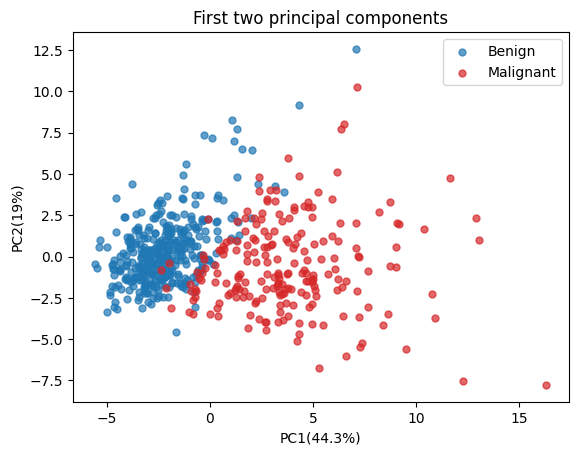

In [ ]:
colors = {0: "tab:blue", 1: "tab:red"}

plt.xlabel('PC1(44.3%)')
plt.ylabel('PC2(19%)')
plt.title('PC1 and PC2')
mask_benign = (diagnosis_binary == 0)
x_benign = pca_X[mask_benign, 0]
y_benign = pca_X[mask_benign, 1]
plt.scatter(x_benign, y_benign, c=colors[0], label='Benign', s=25, alpha=0.7)
plt.legend()

mask_malignant = (diagnosis_binary == 1)
x_malignant = pca_X[mask_malignant, 0]
y_malignant = pca_X[mask_malignant, 1]
plt.scatter(x_malignant, y_malignant, c=colors[1], label='Malignant', s=25, alpha=0.7)
plt.legend()

From this plot we can see that the Benign cases tends to concentrate on x-axis where PC1 is negative while malignant cases concentrate on positive PC1 side.

As the diagnosis cases do not show a clear classification pattern on y-axis, we can conclude that PC1 is closely associated with the diagnosis cases.

However, the points still overlaps especially in the area where x-axis == 0, so there still exist variance that can not be explained by PC1 and PC2.


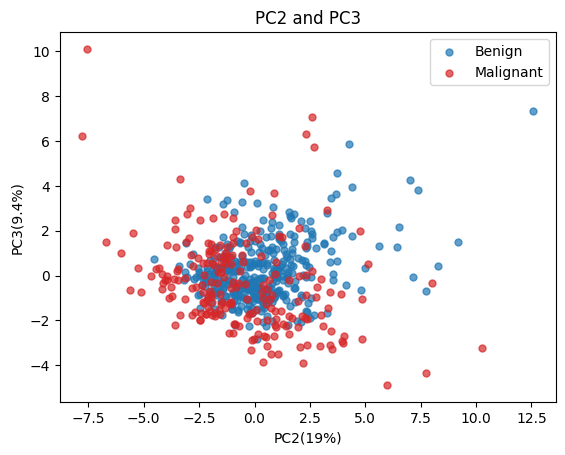

In [ ]:
plt.xlabel('PC2(19%)')
plt.ylabel('PC3(9.4%)')
plt.title('PC2 and PC3')
mask_benign = (diagnosis_binary == 0)
x_benign = pca_X[mask_benign, 1]
y_benign = pca_X[mask_benign, 2]
plt.scatter(x_benign, y_benign, c=colors[0], label='Benign', s=25, alpha=0.7)
plt.legend()

mask_malignant = (diagnosis_binary == 1)
x_malignant = pca_X[mask_malignant, 1]
y_malignant = pca_X[mask_malignant, 2]
plt.scatter(x_malignant, y_malignant, c=colors[1], label='Malignant', s=25, alpha=0.7)
plt.legend()

We also checked that PC2 and PC3 show weaker tendency of classification of malignanity compared with PC1 direction. Thus individually using PC2 and PC3 of them will not be sufficient for classification.

In [ ]:
pca_display_df = pd.DataFrame(
    pca.components_, columns = columns, index = [f'PC{i+1}' for i in range(10)]
)
display(pca_display_df.round(3))

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
PC1,0.219,0.104,0.228,0.221,0.143,0.239,0.258,0.261,0.138,0.064,...,0.228,0.104,0.237,0.225,0.128,0.210,0.229,0.251,0.123,0.132
PC2,-0.234,-0.060,-0.215,-0.231,0.186,0.152,0.060,-0.035,0.190,0.367,...,-0.220,-0.045,-0.200,-0.219,0.172,0.144,0.098,-0.008,0.142,0.275
PC3,-0.009,0.065,-0.009,0.029,-0.104,-0.074,0.003,-0.026,-0.040,-0.023,...,-0.048,-0.042,-0.049,-0.012,-0.260,-0.236,-0.173,-0.170,-0.271,-0.233
PC4,-0.041,0.603,-0.042,-0.053,-0.159,-0.032,-0.019,-0.065,-0.067,-0.049,...,-0.015,0.633,-0.014,-0.026,-0.018,0.091,0.074,-0.006,0.036,0.077
PC5,-0.038,0.049,-0.037,-0.010,0.365,-0.012,-0.086,0.044,0.306,0.044,...,0.004,0.093,-0.007,0.027,0.324,-0.122,-0.189,-0.043,0.245,-0.094
PC6,0.019,-0.032,0.017,-0.002,-0.286,-0.014,-0.009,-0.052,0.356,-0.119,...,-0.000,-0.050,0.009,-0.025,-0.369,0.048,0.028,-0.031,0.499,-0.080
PC7,-0.124,0.011,-0.114,-0.052,-0.141,0.031,-0.108,-0.150,-0.094,0.296,...,-0.010,0.010,-0.000,0.068,-0.109,0.140,-0.060,-0.168,-0.018,0.375
PC8,-0.007,0.131,-0.019,0.035,-0.289,-0.151,-0.073,-0.152,-0.232,-0.177,...,0.043,0.036,0.031,0.079,0.206,0.084,0.072,-0.036,0.228,0.048
PC9,-0.223,0.113,-0.224,-0.196,0.006,-0.168,0.041,-0.112,0.256,-0.124,...,-0.112,0.103,-0.110,-0.081,0.112,-0.101,0.162,0.060,0.065,-0.134
PC10,0.095,0.241,0.086,0.075,-0.069,0.013,-0.136,0.008,0.572,0.081,...,0.077,0.030,0.051,0.070,-0.128,-0.172,-0.312,-0.077,-0.030,0.013


In [ ]:
pca_display_df.loc['PC1'].sort_values(key=abs, ascending=False).head(10)

,PC1
mean_concave_points,0.260854
mean_concavity,0.258400
worst_concave_points,0.250886
mean_compactness,0.239285
worst_perimeter,0.236640
worst_concavity,0.228768
worst_radius,0.227997
mean_perimeter,0.227537
worst_area,0.224871
mean_area,0.220995


The dominating features in PC1 direction are the concavity and perimeter,size, compactness of the cell. Thus PC1 mostly describe the shape and size of a cell and we can see from previous table that most features show positive contribution.

Since we have malignant points gather at larger and positive PC1 direction, we can conclude that the larger size and more concavity are important predictors indicating malignanity

In [ ]:
FAMILY = 'LogisticRegression'
FAMILIES = {
    'LogisticRegression': (
        linear_model.LogisticRegression(max_iter=5000, random_state=0),
        {'C': [0.001, 0.01, 0.1, 1, 10, 100],
         'class_weight': [None, 'balanced']}),
    'SVM': (
        svm.SVC(random_state=0),
        {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'],
         'class_weight': [None, 'balanced']}),
    'DecisionTree': (
        DecisionTreeClassifier(criterion='entropy', random_state=0),
        {'max_depth': [1, 2, 3, 4, 5, None],
         'class_weight': [None, 'balanced']}),
    'kNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
         'weights': ['uniform', 'distance']}),
}

In [ ]:
#Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=0, stratify=y)
#Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'{FAMILY}: train={len(y_train)}, test={len(y_test)}, '
      f'{y.mean():.1%} malignant overall')

LogisticRegression: train=455, test=114, 37.3% malignant overall


In [ ]:
estimator, grid = FAMILIES[FAMILY]
rows = []

for metric in ['accuracy', 'recall', 'precision']:
    gs = GridSearchCV(estimator, grid, scoring=metric, cv=10)
    gs.fit(X_train, y_train)

    y_hat = gs.predict(X_test)
    TN, FP, FN, TP = confusion_matrix(y_true=y_test, y_pred=y_hat).ravel()

    rows.append({
        'tuned for': metric,
        'best_params_': str(gs.best_params_),
        'test recall': round(recall_score(y_test, y_hat), 3),
        'test precision': round(precision_score(y_test, y_hat), 3),
        'test accuracy': round(accuracy_score(y_test, y_hat), 3),
        'FN': FN, 'FP': FP,
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

tuned for                           best_params_  test recall  test precision  test accuracy  FN  FP
 accuracy {'C': 0.1, 'class_weight': 'balanced'}        0.952           0.889          0.939   2   5
   recall   {'C': 1, 'class_weight': 'balanced'}        0.952           0.909          0.947   2   4
precision      {'C': 0.01, 'class_weight': None}        0.905           1.000          0.965   4   0


In [ ]:
for name, (est, grid) in FAMILIES.items():
    gs = GridSearchCV(est, grid, scoring='recall', cv=10)
    gs.fit(X_train, y_train)
    print(f'{name:<20}{gs.best_score_:.3f}  {gs.best_params_}')

LogisticRegression  0.976  {'C': 1, 'class_weight': 'balanced'}
SVM                 0.976  {'C': 1, 'class_weight': 'balanced', 'kernel': 'rbf'}
DecisionTree        0.953  {'class_weight': 'balanced', 'max_depth': 2}
kNN                 0.929  {'n_neighbors': 1, 'weights': 'uniform'}


In [ ]:
print(best_model)

LogisticRegression(C=1, class_weight='balanced', max_iter=5000, random_state=0)


In [ ]:
best_model = linear_model.LogisticRegression(C= 1, class_weight= 'balanced')
best_model.fit(X_train, y_train)
y_hat = best_model.predict(X_test)
#Confusion Matrix
M = confusion_matrix(
    y_true=y_test,
    y_pred=y_hat,
    labels=[0, 1]
)

confusion_df = pd.DataFrame(
    M,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

print('Confusion matrix:')
display(confusion_df)

TN, FP, FN, TP = M.ravel()
print(f'TN={TN}, FP={FP}, FN={FN}, TP={TP}')

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,68,4
Actual 1,2,40


TN=68, FP=4, FN=2, TP=40
